!pip install yfinance

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime

### 1. Data Collection

In [2]:
now = datetime.now()

start = datetime(now.year-15, now.month, now.day)
end = now
ticker = 'GOOG'
df = yf.download(ticker, start, end)
df


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG
Date,,,,,
2011-09-07,13.176095,13.223221,13.012514,13.087766,110645177
2011-09-08,13.199042,13.301189,13.123544,13.170422,95576908
2011-09-09,12.949598,13.191392,12.859296,13.111206,131242091
2011-09-12,13.079624,13.125762,12.768251,12.779601,107216373
2011-09-13,13.064822,13.172396,12.913823,13.126010,94520965
...,...,...,...,...,...
2026-08-31,335.192383,340.408997,333.213656,339.799377,23202000
2026-09-01,331.814575,333.733343,329.076363,332.034434,16313400


### 2. Data Exploration

In [3]:
df.shape

(3771, 5)

In [4]:
df.isna().sum()

Price   Ticker
Close   GOOG      0
High    GOOG      0
Low     GOOG      0
Open    GOOG      0
Volume  GOOG      0
dtype: int64

In [5]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG
count,3771.000000,3771.000000,3771.000000,3771.000000,3.771000e+03
mean,88.671008,89.600291,87.675942,88.604621,4.148569e+07
std,79.794582,80.720798,78.756498,79.699400,3.528941e+07
min,12.225941,12.421349,11.857818,12.090484,1.584340e+05
25%,29.323145,29.570163,29.086572,29.297062,2.163400e+07
50%,57.585072,58.149236,56.849054,57.407753,2.933910e+07
75%,129.017998,130.679018,127.767334,129.286933,4.678895e+07
max,398.541260,403.964470,393.177991,396.563718,4.995615e+08


In [6]:
df.dtypes

Price   Ticker
Close   GOOG      float64
High    GOOG      float64
Low     GOOG      float64
Open    GOOG      float64
Volume  GOOG        int64
dtype: object

In [7]:
df = df.reset_index()
df

Price,Date,Close,High,Low,Open,Volume
Ticker,,GOOG,GOOG,GOOG,GOOG,GOOG
0,2011-09-07,13.176095,13.223221,13.012514,13.087766,110645177
1,2011-09-08,13.199042,13.301189,13.123544,13.170422,95576908
2,2011-09-09,12.949598,13.191392,12.859296,13.111206,131242091
3,2011-09-12,13.079624,13.125762,12.768251,12.779601,107216373
4,2011-09-13,13.064822,13.172396,12.913823,13.126010,94520965
...,...,...,...,...,...,...
3766,2026-08-31,335.192383,340.408997,333.213656,339.799377,23202000
3767,2026-09-01,331.814575,333.733343,329.076363,332.034434,16313400
3768,2026-09-02,333.563446,336.291686,329.306200,330.555389,12995900


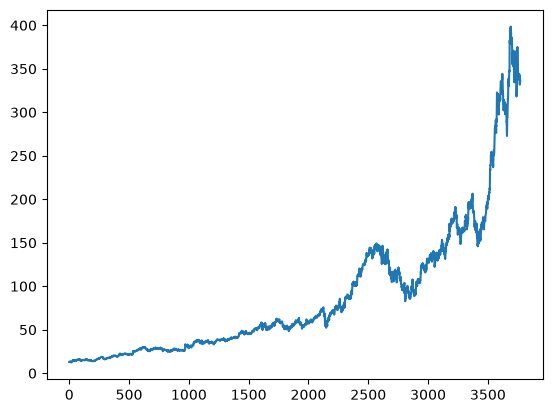

In [8]:
plt.plot(df.Close);

### 3. Feature Engineering

In [9]:
# Calculate 100 days moving average of stock closing price

In [10]:
df['MA_100'] = df['Close'].rolling(100).mean()

In [11]:
df.tail()

Price,Date,Close,High,Low,Open,Volume,MA_100
Ticker,,GOOG,GOOG,GOOG,GOOG,GOOG,
3766,2026-08-31,335.192383,340.408997,333.213656,339.799377,23202000,355.674337
3767,2026-09-01,331.814575,333.733343,329.076363,332.034434,16313400,355.832737
3768,2026-09-02,333.563446,336.291686,329.306200,330.555389,12995900,356.015118
3769,2026-09-03,338.859985,340.628856,336.091794,336.291676,12858300,356.215608
3770,2026-09-04,335.309998,340.179993,333.750000,339.179993,12676800,356.267039


Text(0, 0.5, 'Price')

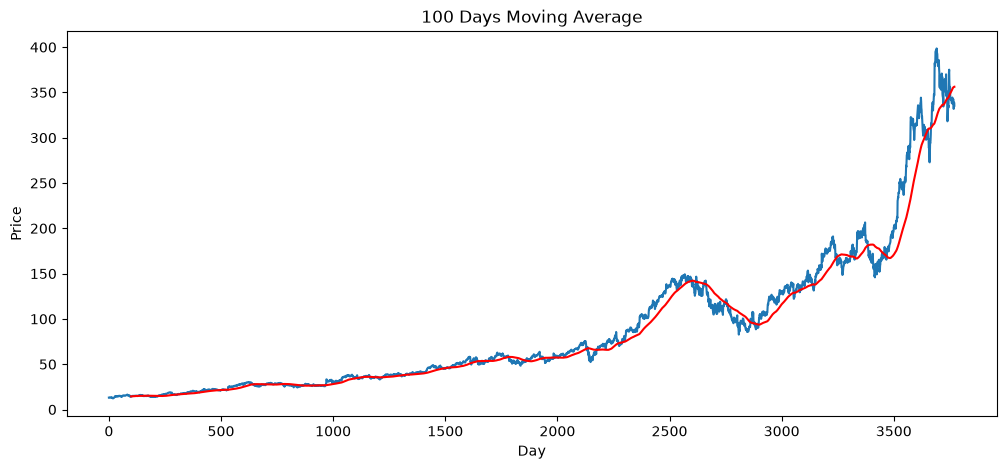

In [12]:
plt.figure(figsize=(12,5))
plt.plot(df.Close);
plt.plot(df['MA_100'],'r');
plt.title('100 Days Moving Average')
plt.xlabel('Day')
plt.ylabel('Price')

In [13]:
df['MA_200'] = df['Close'].rolling(200).mean()
df.tail()

Price,Date,Close,High,Low,Open,Volume,MA_100,MA_200
Ticker,,GOOG,GOOG,GOOG,GOOG,GOOG,,
3766,2026-08-31,335.192383,340.408997,333.213656,339.799377,23202000,355.674337,333.270023
3767,2026-09-01,331.814575,333.733343,329.076363,332.034434,16313400,355.832737,333.495688
3768,2026-09-02,333.563446,336.291686,329.306200,330.555389,12995900,356.015118,333.771539
3769,2026-09-03,338.859985,340.628856,336.091794,336.291676,12858300,356.215608,334.084545
3770,2026-09-04,335.309998,340.179993,333.750000,339.179993,12676800,356.267039,334.336813


Text(0, 0.5, 'Price')

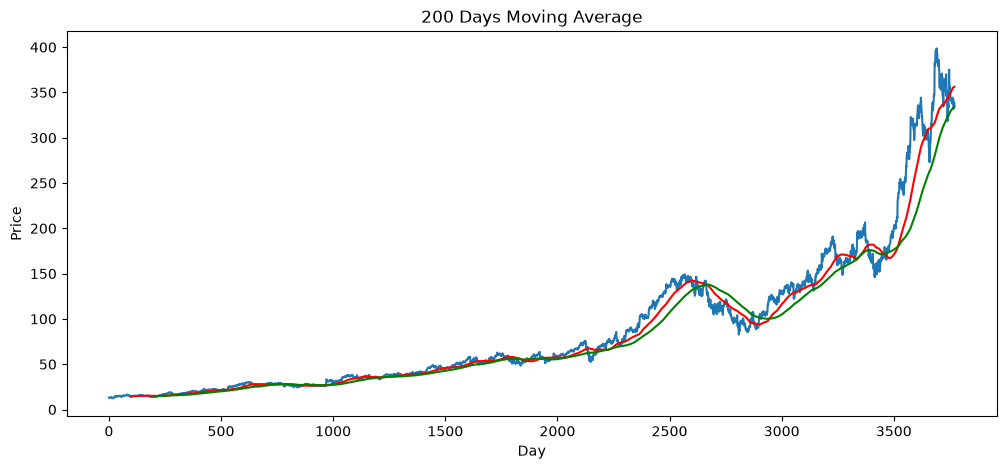

In [14]:
plt.figure(figsize=(12,5))
plt.plot(df.Close);
plt.plot(df['MA_100'],'r');
plt.plot(df['MA_200'],'g');
plt.title('200 Days Moving Average')
plt.xlabel('Day')
plt.ylabel('Price')

In [15]:
#Calculating  % change in each trading session

In [16]:
df['Percentage Change'] = df.Close.pct_change()
df[['Close','Percentage Change']]

Price,Close,Percentage Change
Ticker,GOOG,
0,13.176095,NaN
1,13.199042,0.001742
2,12.949598,-0.018899
3,13.079624,0.010041
4,13.064822,-0.001132
...,...,...
3766,335.192383,-0.021786
3767,331.814575,-0.010077
3768,333.563446,0.005271


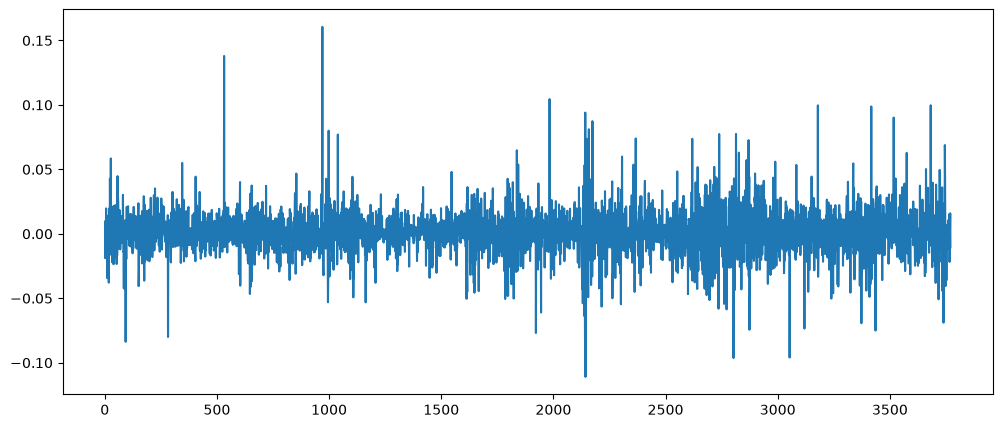

In [17]:
plt.figure(figsize=(12,5))
plt.plot(df['Percentage Change']);

### 4. Data Preprocessing

In [18]:
df.shape

(3771, 9)

In [19]:
#Splitting training and testing data
data_train = pd.DataFrame(df.Close[0:int(len(df)*0.7)])
data_test = pd.DataFrame(df.Close[int(len(df)*0.7):int(len(df))])

In [20]:
data_train

Ticker,GOOG
0,13.176095
1,13.199042
2,12.949598
3,13.079624
4,13.064822
...,...
2634,131.428650
2635,133.257339
2636,133.625366
2637,132.909134


In [21]:
data_test

Ticker,GOOG
2639,133.047821
2640,130.882339
2641,125.277901
2642,126.084274
2643,132.609955
...,...
3766,335.192383
3767,331.814575
3768,333.563446
3769,338.859985


In [22]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

In [23]:
data_training_array = scaler.fit_transform(data_train)
data_training_array.shape

(2639, 1)

### 5. Sequence Creation

In [24]:
x_train = []
y_train = []

for i in range(100,data_training_array.shape[0]):
    x_train.append(data_training_array[i-100:i])
    y_train.append(data_training_array[i,0])

x_train, y_train = np.array(x_train), np.array(y_train)

### 6. Model Building

In [25]:
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [31]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [32]:
 # ML Models
from keras.models import Sequential
from keras.layers import Dense, LSTM, Input

In [35]:
model = Sequential()
model.add(Input(shape=(100,1)))
model.add(LSTM(units=128, activation='tanh', return_sequences=True))
model.add(LSTM(units=64))
model.add(Dense(25))
model.add(Dense(1))

### 7. Model Training 

In [36]:
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(x_train, y_train, epochs=50)

Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 18s 142ms/step - loss: 0.0037
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 14s 170ms/step - loss: 2.1418e-04
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 14s 172ms/step - loss: 2.3052e-04
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 11s 136ms/step - loss: 2.0128e-04
Epoch 5/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 11s 133ms/step - loss: 2.0825e-04
Epoch 6/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 9s 110ms/step - loss: 2.0450e-04
Epoch 7/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 12s 126ms/step - loss: 2.0015e-04
Epoch 8/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 11s 134ms/step - loss: 2.0630e-04
Epoch 9/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 9s 116ms/step - loss: 2.1496e-04
Epoch 10/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 10s 127ms/step - loss: 2.0329e-04
Epoch 11/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 10s 123ms/step - loss: 1.7133e-04
Epoch 12/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 10s 120ms/step - loss: 1.8268e-04
Epoch 13/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 10s 121ms/step - loss: 1.5512e-04
Epoch 14/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 10s 122ms/step - loss: 1.64

In [38]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                        │ (None, 100, 128)            │          66,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_7 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 25)                  │           1,625 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 352,859 (1.35 MB)

 Trainable params: 117,619 (459.45 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 235,240 (918.91 KB)

In [39]:
model.save('stock_prediction_model.keras')

### 8. Model Testing

In [42]:
past_100_days = data_train.tail(100)
final_df = pd.concat([past_100_days, data_test], ignore_index=True)
final_df

Ticker,GOOG
0,138.741882
1,137.544724
2,135.430252
3,136.606125
4,140.085144
...,...
1227,335.192383
1228,331.814575
1229,333.563446
1230,338.859985


In [43]:
input_data = scaler.fit_transform(final_df)

In [48]:
x_test = []
y_test = []

for i in range(100,input_data.shape[0]):
    x_test.append(input_data[i-100:i])
    y_test.append(input_data[i,0])
x_test, y_test = np.array(x_test), np.array(y_test)

### 9. Make Predictions

In [49]:
y_predict = model.predict(x_test)

36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step


In [50]:
y_predict = scaler.inverse_transform(y_predict.reshape(-1,1)).flatten()
y_test = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()


In [51]:
y_predict

array([133.99408, 133.75586, 132.42159, ..., 331.79272, 333.757  ,
       339.55823], shape=(1132,), dtype=float32)

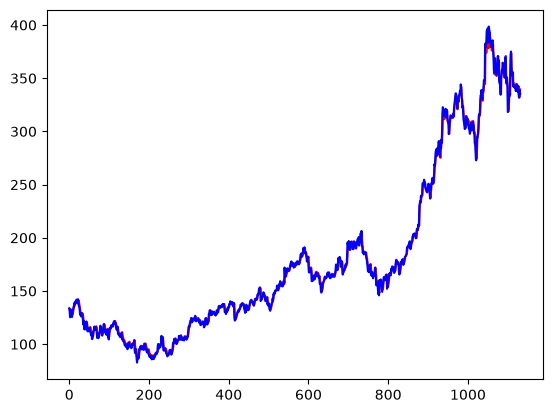

In [53]:
plt.plot(y_predict, 'r', label='Predicted Price');
plt.plot(y_test, 'b', label='Original; Price');


### 10. Model Evaluation

In [56]:
#MSE

from sklearn.metrics import mean_squared_error

In [57]:
mse = mean_squared_error(y_test,y_predict)
mse

17.408869157545684